# House Prices — Analyse Exploratoire des Données (EDA)

Nom et prénom Skander Trigui  
Classe :M1 BDIA  

Ce notebook contient une analyse exploratoire complète du dataset House Prices: Advanced Regression Techniques dans le but de comprendre les données, identifier les variables importantes et préparer efficacement les futures étapes de modélisation et de prédiction.

## 
 Imports & Configuration

In [1]:
#ci dessous tout lew import utilisés pas que pour EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import skew, norm

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
import lightgbm as lgb

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


---
PARTIE 1 — Analyse Exploratoire (EDA)
---

## 1.1 Chargement des données

On charge les fichiers train et test. Le train contient la variable cible `SalePrice` — le test en est dépourvu, c'est ce qu'on devra prédire.

In [2]:
train = pd.read_csv(r'C:\Users\skand\OneDrive\Bureau\dauphine\train.csv')
test  = pd.read_csv(r'C:\Users\skand\OneDrive\Bureau\dauphine\test.csv')

print(f'Train : {train.shape[0]} lignes, {train.shape[1]} colonnes')
print(f'Test  : {test.shape[0]} lignes, {test.shape[1]} colonnes')
print(f'\nPrix min : {train.SalePrice.min():,.0f}$  |  Prix max : {train.SalePrice.max():,.0f}$  |  Médiane : {train.SalePrice.median():,.0f}$')

Train : 1460 lignes, 81 colonnes
Test  : 1459 lignes, 80 colonnes

Prix min : 34,900$  |  Prix max : 755,000$  |  Médiane : 163,000$


In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1.2 Vue d'ensemble du dataset

Le dataset contient **79 variables explicatives** décrivant pratiquement tous les aspects d'une maison résidentielle à Ames, Iowa : surface habitable, qualité des matériaux, année de construction, type de garage, etc.  
On distingue rapidement deux grandes familles : les variables numériques (surfaces, années, comptages) et les variables catégorielles (qualité, matériaux, zonage).

In [4]:
# Séparation numériques / catégorielles
num_features = train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = train.select_dtypes(include=['object']).columns.tolist()

# Retirer Id et SalePrice de la liste
num_features = [c for c in num_features if c not in ['Id', 'SalePrice']]

print(f'Variables numériques  : {len(num_features)}')
print(f'Variables catégorielles : {len(cat_features)}')
print(f'\nNumériques : {num_features[:10]}...')
print(f'\nCatégorielles : {cat_features[:10]}...')

Variables numériques  : 36
Variables catégorielles : 43

Numériques : ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2']...

Catégorielles : ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']...


In [5]:
# Statistiques descriptives pour les variables numériques clés
train[['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt', 'GarageArea']].describe().round(1)

,SalePrice,GrLivArea,TotalBsmtSF,OverallQual,YearBuilt,GarageArea
count,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0
mean,180921.2,1515.5,1057.4,6.1,1971.3,473.0
std,79442.5,525.5,438.7,1.4,30.2,213.8
min,34900.0,334.0,0.0,1.0,1872.0,0.0
25%,129975.0,1129.5,795.8,5.0,1954.0,334.5
50%,163000.0,1464.0,991.5,6.0,1973.0,480.0
75%,214000.0,1776.8,1298.2,7.0,2000.0,576.0
max,755000.0,5642.0,6110.0,10.0,2010.0,1418.0


1.3 Analyse des valeurs manquantes

Avant de modéliser quoi que ce soit, il faut comprendre **pourquoi** certaines valeurs sont manquantes.  
Dans ce dataset, beaucoup de NA sont en réalité des NA "logiques" : une maison sans piscine aura NA dans `PoolQC`, pas parce que la donnée est absente, mais parce qu'il n'y a tout simplement pas de piscine.  
Ce n'est pas le même traitement que les NA vraiment problématiques (comme `LotFrontage`).

In [6]:
# Calcul des valeurs manquantes
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_pct = (missing_train / len(train) * 100).round(1)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing_train,
    'Pourcentage (%)': missing_pct
})
print(missing_df.to_string())

              Valeurs manquantes  Pourcentage (%)
PoolQC                      1453             99.5
MiscFeature                 1406             96.3
Alley                       1369             93.8
Fence                       1179             80.8
MasVnrType                   872             59.7
FireplaceQu                  690             47.3
LotFrontage                  259             17.7
GarageType                    81              5.5
GarageYrBlt                   81              5.5
GarageFinish                  81              5.5
GarageQual                    81              5.5
GarageCond                    81              5.5
BsmtExposure                  38              2.6
BsmtFinType2                  38              2.6
BsmtQual                      37              2.5
BsmtCond                      37              2.5
BsmtFinType1                  37              2.5
MasVnrArea                     8              0.5
Electrical                     1              0.1


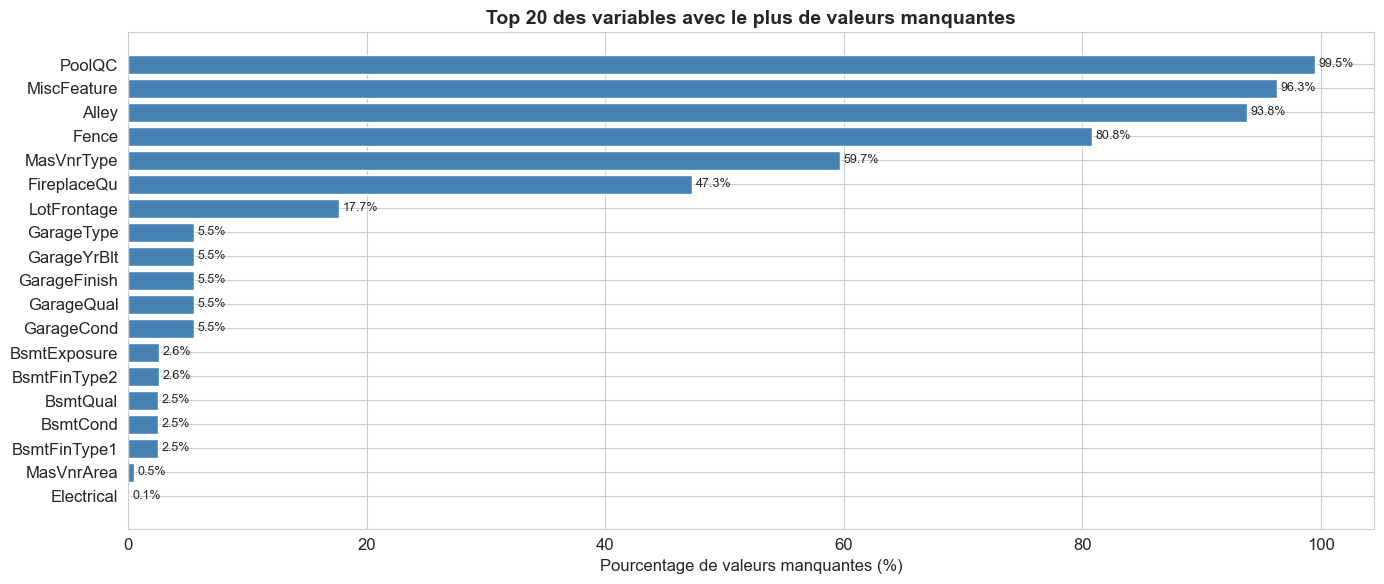

In [7]:
# Visualisation — heatmap des valeurs manquantes
fig, ax = plt.subplots(figsize=(14, 6))
missing_top20 = missing_df.head(20)
bars = ax.barh(missing_top20.index[::-1], missing_top20['Pourcentage (%)'][::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Pourcentage de valeurs manquantes (%)')
ax.set_title('Top 20 des variables avec le plus de valeurs manquantes', fontsize=14, fontweight='bold')
for bar, val in zip(bars, missing_top20['Pourcentage (%)'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Interprétation :Les variables avec le plus de NA (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`) sont toutes des caractéristiques optionnelles — un NA signifie "absence de cette caractéristique", pas une donnée manquante au sens statistique.  
En revanche, `LotFrontage` (~18% de NA) est une surface numérique continue : ici, le NA est probablement dû à une non-collecte de la donnée, ce qui nécessite une imputation réfléchie (par la médiane du quartier, par exemple).

1.4 Analyse de la variable cible — SalePrice

La première chose à faire avec une régression, c'est d'examiner la distribution de la variable qu'on cherche à prédire.  
Une distribution asymétrique comme celle des prix immobiliers va pénaliser les modèles linéaires — une transformation logarithmique corrige ça.

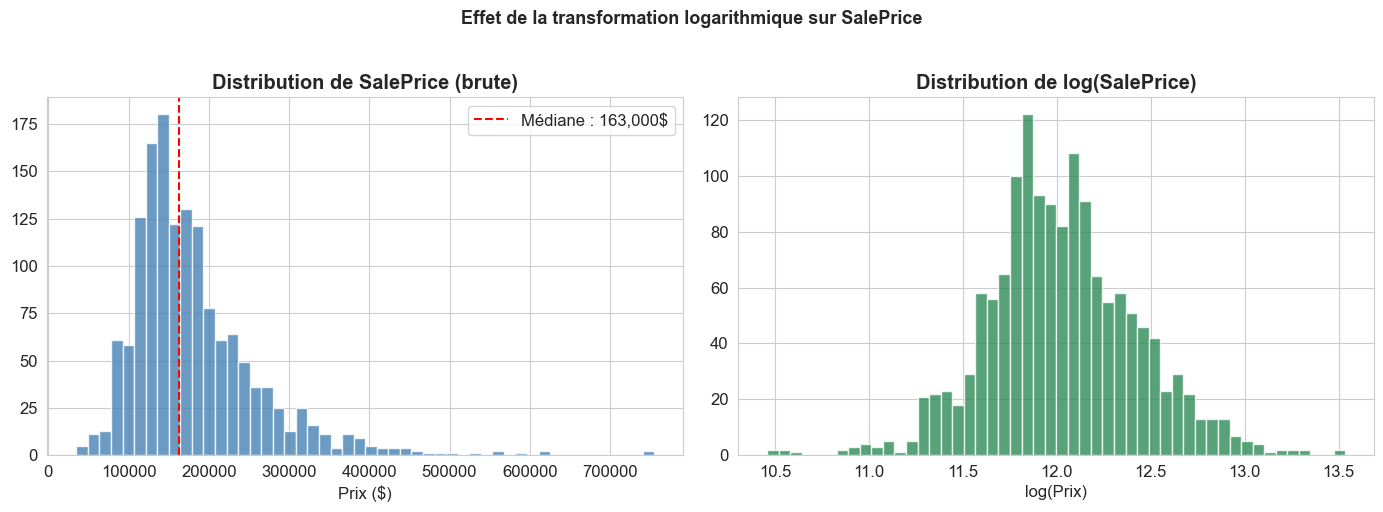

Skewness brute : 1.881
Skewness après log : 0.121


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution brute
axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(train['SalePrice'].median(), color='red', linestyle='--', label=f"Médiane : {train['SalePrice'].median():,.0f}$")
axes[0].set_title('Distribution de SalePrice (brute)', fontweight='bold')
axes[0].set_xlabel('Prix ($)')
axes[0].legend()

# Distribution après transformation log
log_price = np.log1p(train['SalePrice'])
axes[1].hist(log_price, bins=50, color='seagreen', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution de log(SalePrice)', fontweight='bold')
axes[1].set_xlabel('log(Prix)')

plt.suptitle('Effet de la transformation logarithmique sur SalePrice', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness brute : {skew(train.SalePrice):.3f}')
print(f'Skewness après log : {skew(log_price):.3f}')

Interprétation : La distribution brute est fortement asymétrique à droite (skewness ~ 1.88) — quelques maisons très chères tirent la moyenne vers le haut.  
Après transformation log, la distribution devient quasi-normale (skewness ~ 0.12), ce qui est exactement ce que les modèles linéaires supposent. C'est aussi la métrique d'évaluation de Kaggle (RMSE sur log), donc la transformation est doublement justifiée.

 1.5 Variables numériques — distributions et skewness

In [9]:
# Variables numériques les plus asymétriques
skewness = train[num_features].apply(lambda x: skew(x.dropna()))
skewness = skewness.sort_values(ascending=False)
highly_skewed = skewness[abs(skewness) > 0.75]
print(f'{len(highly_skewed)} variables avec |skewness| > 0.75 :')
print(highly_skewed.head(20).round(2).to_string())

21 variables avec |skewness| > 0.75 :
MiscVal          24.45
PoolArea         14.81
LotArea          12.20
3SsnPorch        10.29
LowQualFinSF      9.00
KitchenAbvGr      4.48
BsmtFinSF2        4.25
ScreenPorch       4.12
BsmtHalfBath      4.10
EnclosedPorch     3.09
MasVnrArea        2.67
OpenPorchSF       2.36
LotFrontage       2.16
BsmtFinSF1        1.68
WoodDeckSF        1.54
TotalBsmtSF       1.52
MSSubClass        1.41
1stFlrSF          1.38
GrLivArea         1.37
BsmtUnfSF         0.92


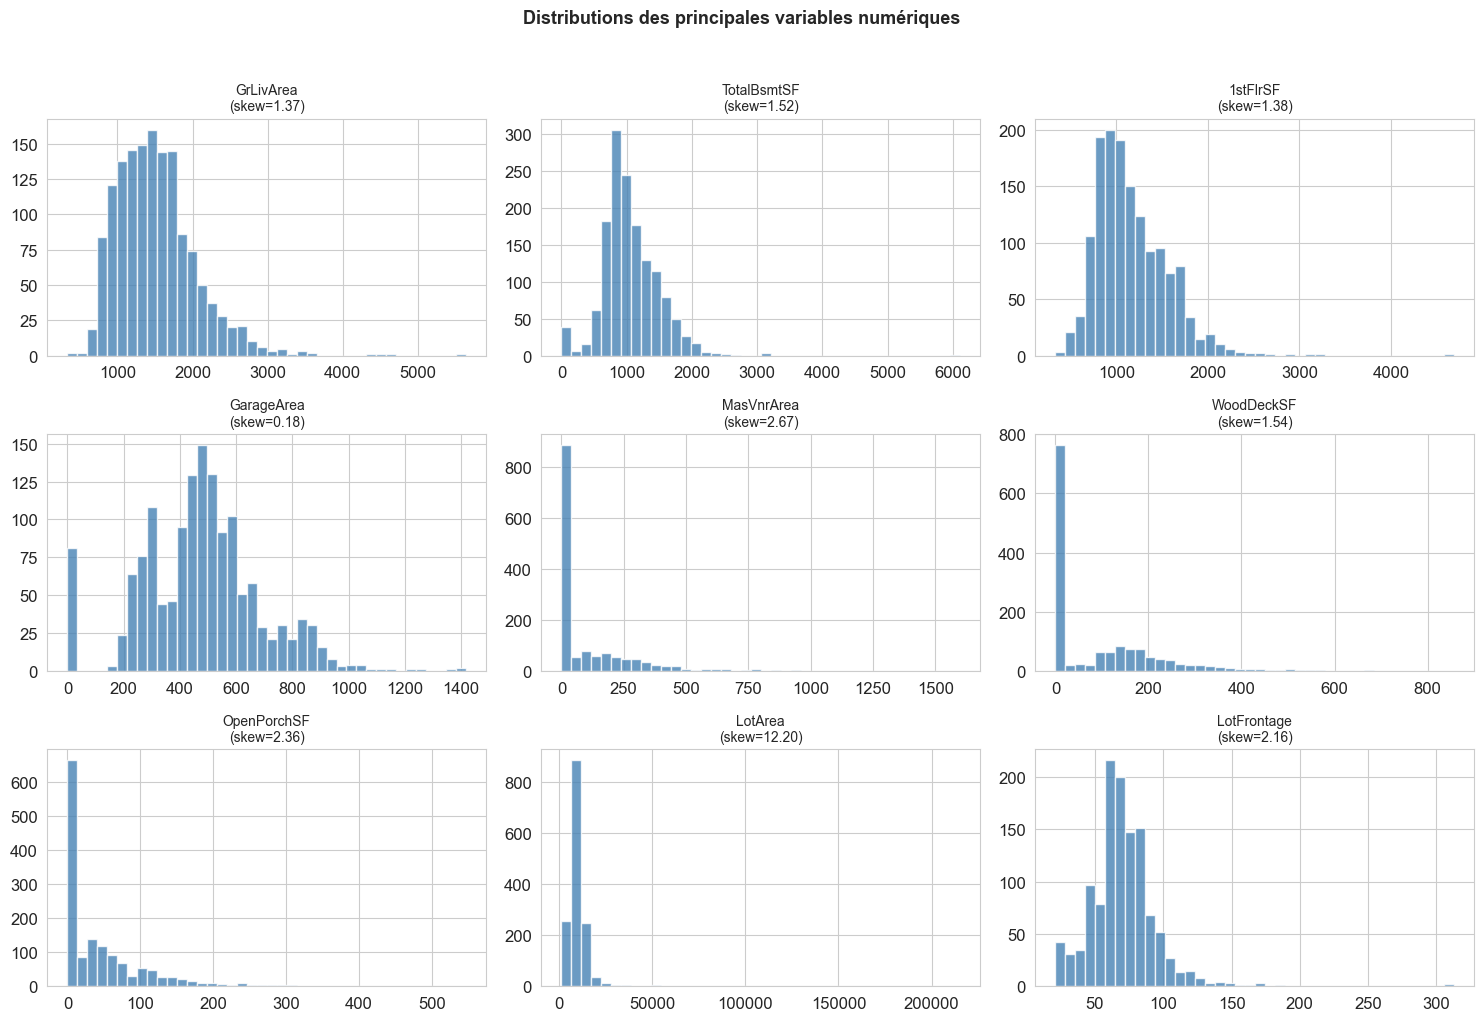

In [10]:
# Distribution des 9 variables numériques les plus corrélées au prix
top_num = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'MasVnrArea',
           'WoodDeckSF', 'OpenPorchSF', 'LotArea', 'LotFrontage']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), top_num):
    train[col].dropna().hist(ax=ax, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{col}\n(skew={skew(train[col].dropna()):.2f})', fontsize=10)
    ax.set_ylabel('')
plt.suptitle('Distributions des principales variables numériques', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Interprétation : La plupart des variables de surface (`LotArea`, `MasVnrArea`, `WoodDeckSF`) sont très asymétriques — beaucoup de petites valeurs et quelques valeurs extrêmes. Ces variables devront être transformées (log1p) pour ne pas perturber les modèles linéaires.

 1.6 Variables catégorielles — impact sur le prix

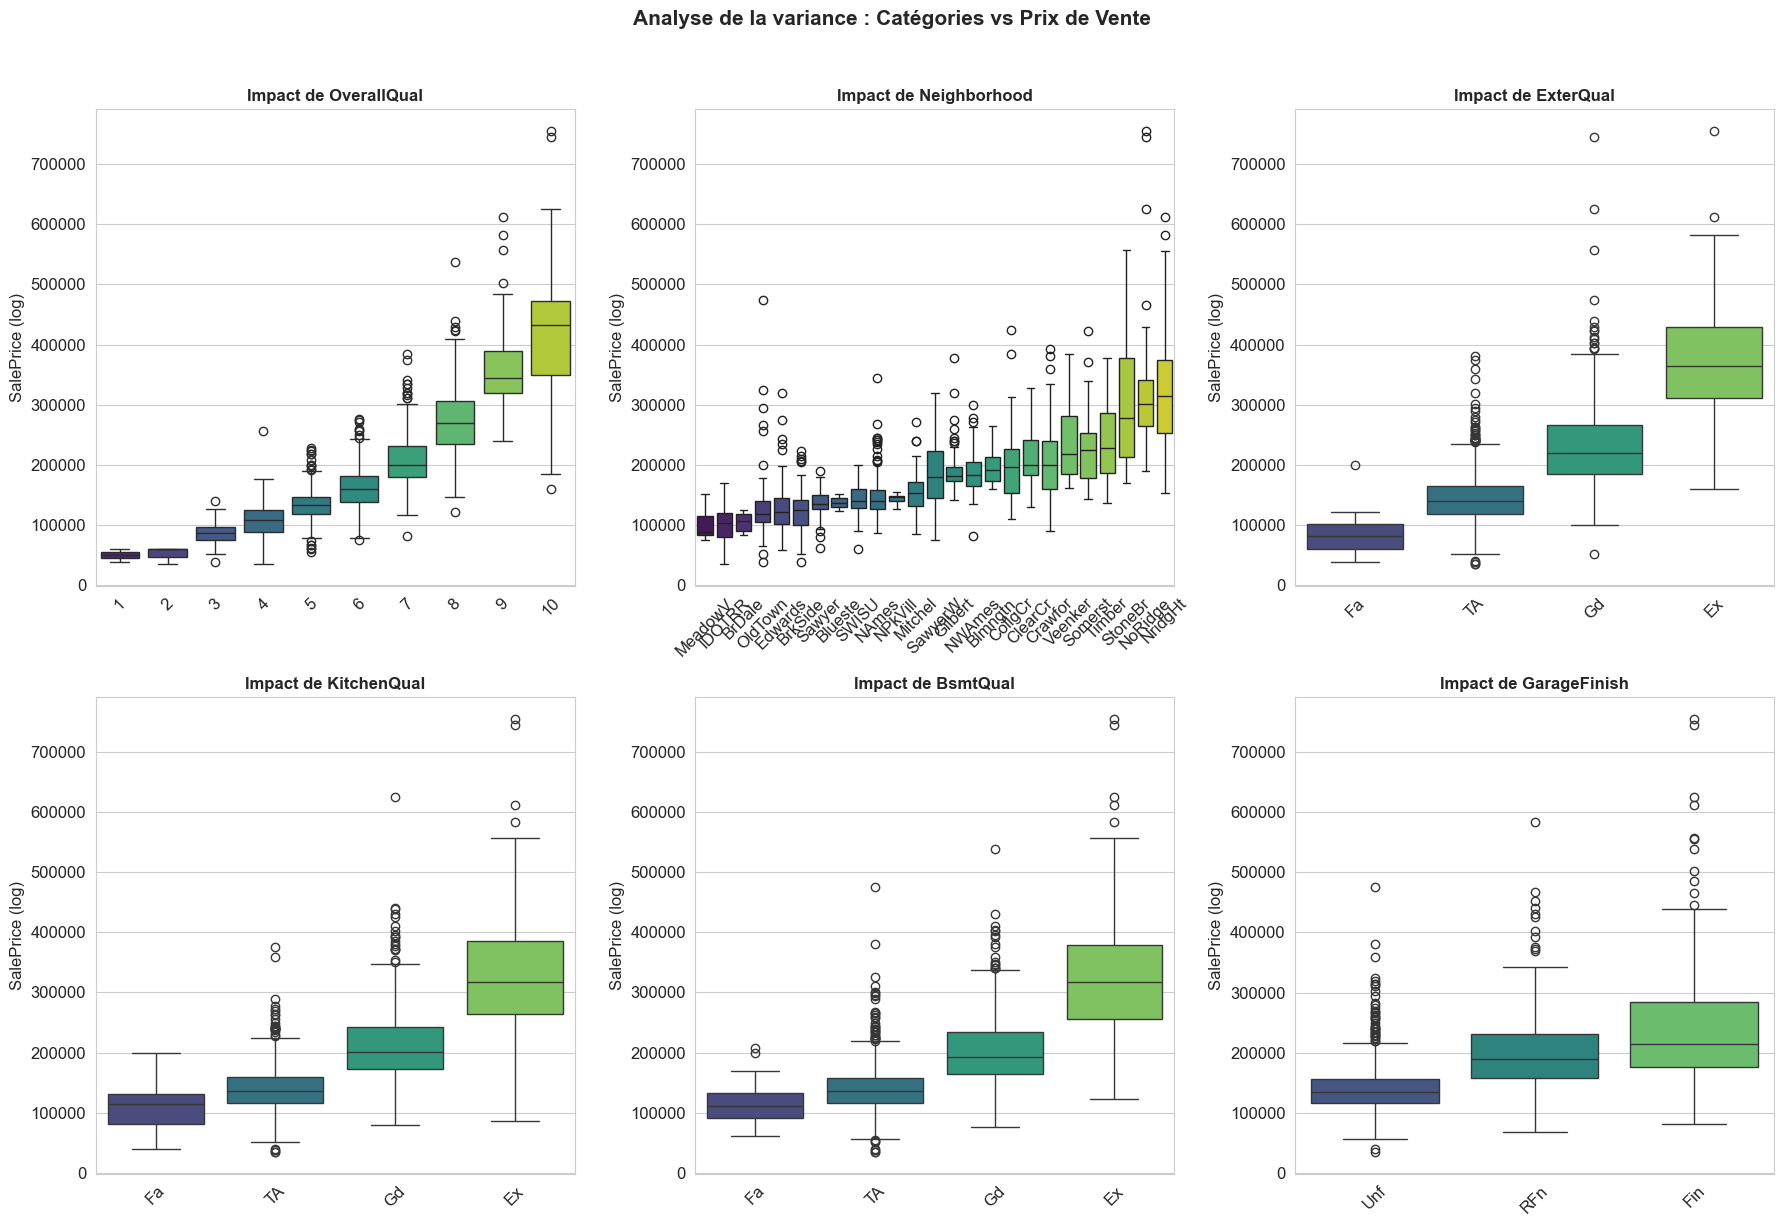

In [11]:
# Boxplots des variables catégorielles les plus influentes
top_cat = ['OverallQual', 'Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, col in zip(axes.flatten(), top_cat):
    # On trie les catégories par médiane pour une lecture plus claire
    order = train.groupby(col)['SalePrice'].median().sort_values().index
    
    # Utilisation de Seaborn au lieu du boxplot Pandas
    sns.boxplot(x=col, y='SalePrice', data=train, ax=ax, order=order, palette='viridis')
    
    ax.set_title(f'Impact de {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('SalePrice (log)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Analyse de la variance : Catégories vs Prix de Vente', y=1.02, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


Interprétation : `OverallQual` est sans surprise la variable la plus discriminante — les maisons notées 9-10 valent en médiane 3 à 4 fois plus que celles notées 1-3. Le quartier (`Neighborhood`) crée aussi une forte dispersion : `NoRidge` et `NridgHt` se distinguent nettement des quartiers plus populaires comme `MeadowV` ou `BrDale`. Ces deux variables seront parmi les plus importantes dans nos modèles.

1.7 Analyse bivariée — corrélations

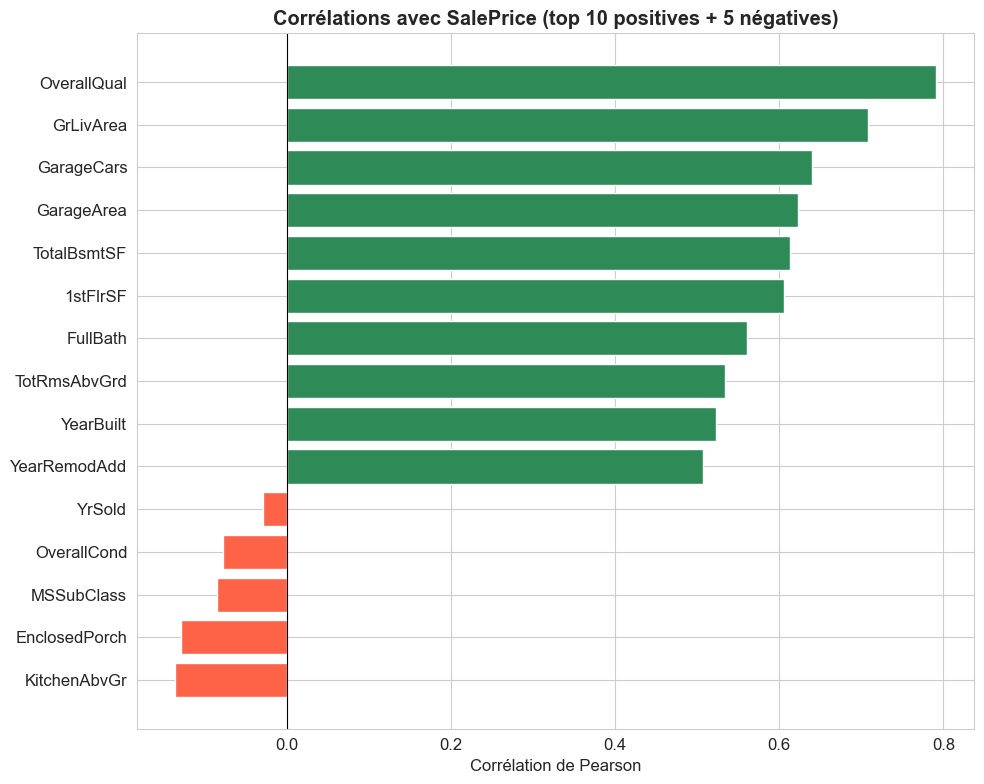

Top 10 corrélations positives :
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507


In [12]:
# Corrélation avec SalePrice — top 15 variables
corr_matrix = train[num_features + ['SalePrice']].corr()
corr_target = corr_matrix['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top15 = pd.concat([corr_target.head(10), corr_target.tail(5)])
colors = ['seagreen' if v > 0 else 'tomato' for v in top15.values]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corrélations avec SalePrice (top 10 positives + 5 négatives)', fontweight='bold')
ax.set_xlabel('Corrélation de Pearson')
plt.tight_layout()
plt.show()

print('Top 10 corrélations positives :')
print(corr_target.head(10).round(3).to_string())

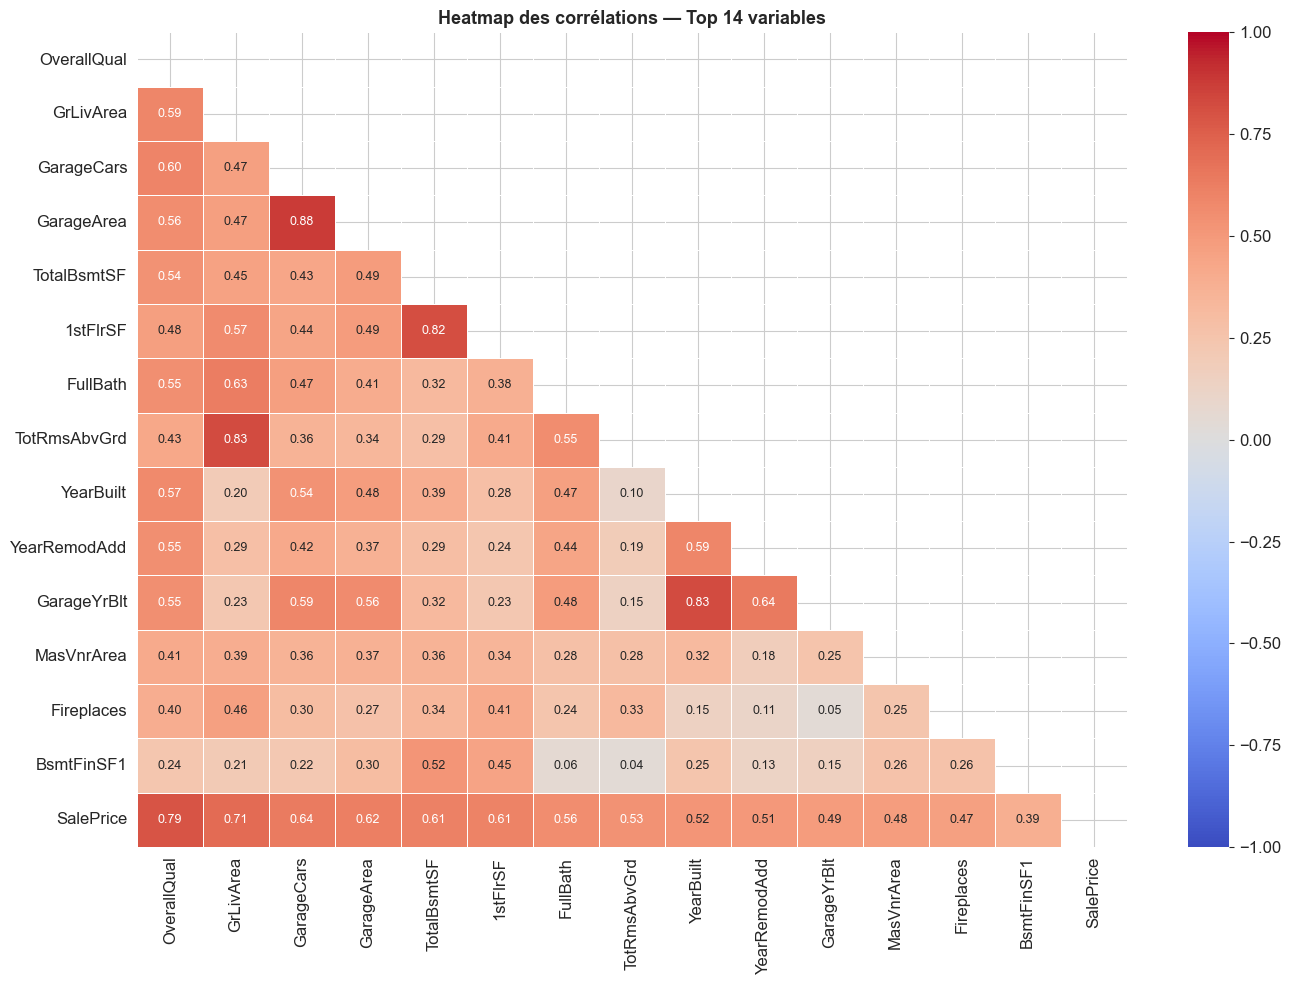

In [13]:
# Heatmap des corrélations entre les 15 variables les plus corrélées
top_vars = corr_target.head(14).index.tolist() + ['SalePrice']
corr_sub = train[top_vars].corr()

plt.figure(figsize=(14, 10))
mask = np.zeros_like(corr_sub)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_sub, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9})
plt.title('Heatmap des corrélations — Top 14 variables', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

Interprétation : Les variables les plus corrélées au prix sont `OverallQual` (0.79), `GrLivArea` (0.71) et `GarageCars` (0.64). Ces résultats sont cohérents avec l'intuition : la qualité globale et la surface habitable sont les premiers critères qu'un acheteur regarde.  
On note aussi une **multicolinéarité** entre `GarageArea` et `GarageCars` (r ~ 0.88), et entre `GrLivArea` et `TotRmsAbvGrd` (r ~ 0.83) — on devra en tenir compte pour les modèles régularisés.

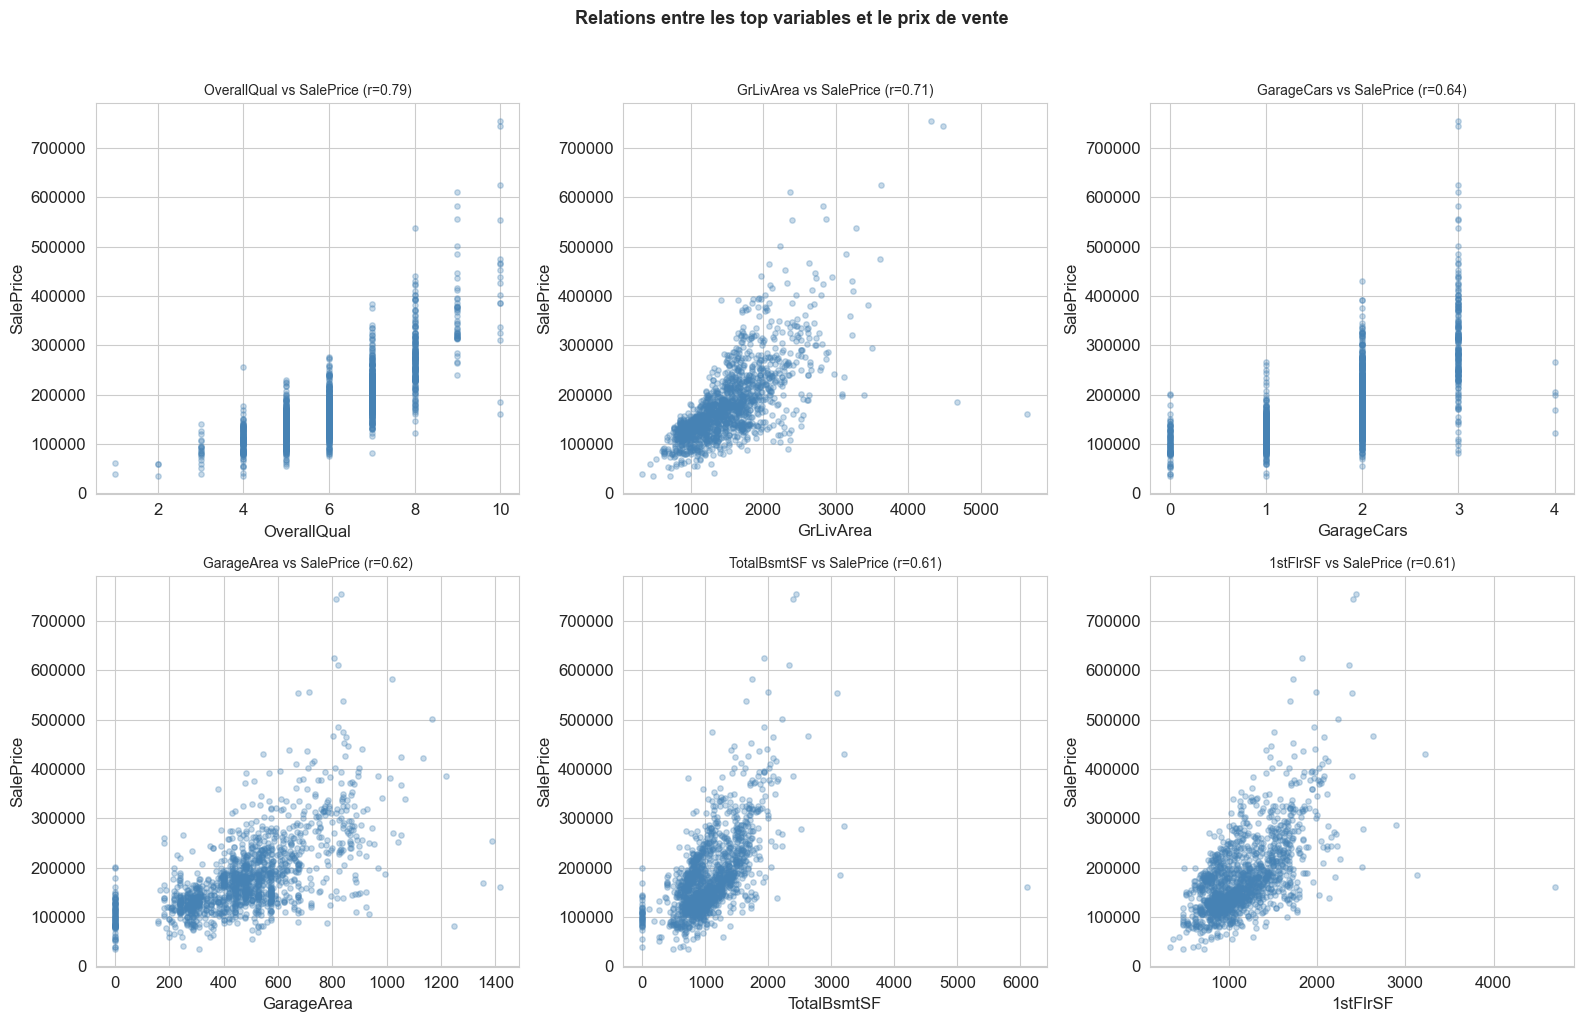

In [14]:
# Scatter plots des 6 variables les plus corrélées
top6 = corr_target.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), top6):
    ax.scatter(train[col], train['SalePrice'], alpha=0.3, color='steelblue', s=15)
    ax.set_xlabel(col)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{col} vs SalePrice (r={corr_target[col]:.2f})', fontsize=10)
plt.suptitle('Relations entre les top variables et le prix de vente', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

1.8 Détection et suppression des outliers

Sur les scatter plots ci-dessus, on voit quelques points aberrants — notamment des maisons avec une très grande surface (`GrLivArea` > 4000 sqft) mais vendues à un prix étonnamment bas.  
Ces points peuvent fortement déstabiliser un modèle linéaire. On les retire, mais de façon chirurgicale : on ne touche qu'aux outliers clairement identifiables et documentés.

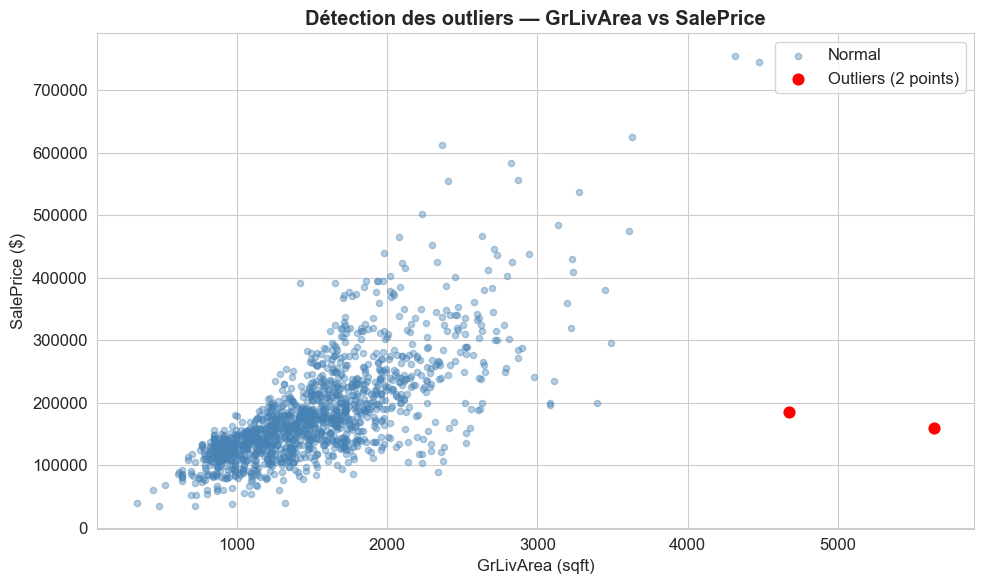

Outliers détectés : 2 maisons
      GrLivArea  SalePrice  OverallQual Neighborhood
523        4676     184750           10      Edwards
1298       5642     160000           10      Edwards


In [15]:
# Visualisation des outliers GrLivArea vs SalePrice
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, color='steelblue', s=20, label='Normal')
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
ax.scatter(outliers['GrLivArea'], outliers['SalePrice'], color='red', s=60, zorder=5, label=f'Outliers ({len(outliers)} points)')
ax.set_xlabel('GrLivArea (sqft)')
ax.set_ylabel('SalePrice ($)')
ax.set_title('Détection des outliers — GrLivArea vs SalePrice', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Outliers détectés : {len(outliers)} maisons')
print(outliers[['GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood']])

In [16]:
# Suppression des outliers
train = train.drop(outliers.index)
print(f'Dataset après suppression des outliers : {train.shape}')

Dataset après suppression des outliers : (1458, 81)


Interprétation : Les 2 outliers supprimés sont des maisons de très grande superficie vendue bien en dessous du marché — probablement des ventes atypiques (vente familiale, saisie judiciaire). Les conserver dans le dataset perturberait la relation surface→prix que tous nos modèles cherchent à capturer.

## 1.9 Conclusion EDA

Après cette analyse exploratoire, on peut déjà tirer plusieurs observations importantes pour la suite du projet.  
Certaines variables ressortent clairement comme très liées au prix des maisons, notamment `OverallQual`, `GrLivArea`, `GarageCars`, `TotalBsmtSF`, `FullBath` et `YearBuilt`. On peut donc s’attendre à ce qu’elles aient un poids important dans les modèles de prédiction.

On remarque aussi que beaucoup de valeurs manquantes ne sont pas forcément des erreurs mais correspondent simplement à l’absence d’un équipement, comme un garage, une piscine ou une cheminée. Dans ces cas-là, remplacer les NA par `"None"` ou `0` semble plus logique.

Pour d’autres variables comme `LotFrontage`, les valeurs manquantes paraissent plus problématiques et devront être imputées de manière plus cohérente, par exemple avec la médiane du quartier.

La variable cible `SalePrice` est assez asymétrique, ce qui peut compliquer l’apprentissage des modèles. Une transformation logarithmique sera donc appliquée afin d’obtenir une distribution plus stable. Plusieurs variables numériques présentent aussi une forte asymétrie et devront probablement être transformées.

Enfin, quelques relations fortes entre variables montrent un début de multicolinéarité, notamment entre `GarageArea` et `GarageCars` ou encore `GrLivArea` et `TotRmsAbvGrd`. Ce n’est pas forcément bloquant mais cela devra être pris en compte dans certains modèles.

Deux valeurs aberrantes ont également été identifiées puis supprimées car elles avaient une surface très élevée mais un prix anormalement faible, ce qui risquait de perturber l’entraînement.